Submitted by **AMARNATH (MS22070)**
## Introduction

### Kuramoto Model

The dynamics of $N$ coupled oscillators is given by:

$$
\frac{d\theta_i}{dt} = \omega_i + K \sum_{j=1}^{N} A_{ij} \sin(\theta_j - \theta_i), \quad i = 1,2,\dots,N
$$

where:
- $\theta_i$ is the phase of the $i$-th oscillator  
- $\omega_i$ is its natural frequency  
- $K$ is the coupling strength  
- $A_{ij}$ represents the adjacency matrix  

---

###  Network Structure: Watts–Strogatz Model

The oscillators are placed on a **Watts–Strogatz small-world network**, characterized by:
- $N$: number of nodes  
- $k$: number of nearest neighbors  
- $p$: rewiring probability  

This model interpolates between:
- **Regular lattice ($p = 0$)** → local connections  
- **Random network ($p = 1$)** → random connections  

Intermediate values of $p$ produce **small-world networks**, combining clustering and short path lengths.

---

###  Measure of Synchronization

The level of synchronization is quantified using the **global order parameter**:

$$
r(t) = \left| \frac{1}{N} \sum_{j=1}^{N} e^{i\theta_j(t)} \right|
$$

where:
- $r(t) \in [0,1]$
- $r \approx 0$ → incoherent state  
- $r \approx 1$ → synchronized state  

---

###  Objective of the Study

The objective of this work is to:

- Investigate how synchronization emerges as the coupling strength $K$ increases  
- Identify the critical coupling strength $K_c$  
- Analyze the time evolution using $r(t)$  
- Study the effect of network topology ($p$)  

---

###  Approach

The system is simulated numerically by:
- Random initial phases  
- Gaussian-distributed natural frequencies  
- Time evolution of Kuramoto equations  

Results are analyzed using:
- $r(t)$ vs time  
- $r$ vs $K$  
- Comparison across different $p$  

In [4]:
import numpy as np
import random
import matplotlib.pyplot as plt


In [ ]:
def watts_strogatz(N, k, p):
    A = np.zeros((N, N))

    # ring lattice
    for i in range(N):
        for j in range(1, k//2 + 1):
            A[i, (i + j) % N] = 1
            A[i, (i - j) % N] = 1

    # rewiring
    for i in range(N):
        for j in range(1, k//2 + 1):
            neighbor = (i + j) % N

            if i < neighbor:  #  avoid double counting

                if random.random() < p:
                    A[i, neighbor] = 0
                    A[neighbor, i] = 0

                    possible = list(set(range(N)) - {i} - set(np.where(A[i]==1)[0]))
                    new = random.choice(possible)

                    A[i, new] = 1
                    A[new, i] = 1

    return A


In [99]:

N = 100
k = 6 #degree of networl
p = 0.1

A = watts_strogatz(N, k, p)

theta = np.random.uniform(0, 2*np.pi, N)
omega = np.random.normal(0, 1, N)




In [105]:

def simulate(A, omega, K, theta0, dt=0.01, T=100):
    N = len(omega)
    steps = int(T/dt)
    theta = theta0.copy()

    r_list = []

    degree = np.sum(A, axis=1)

    for _ in range(steps):

        interaction = np.sum(A * np.sin(theta[None, :] - theta[:, None]), axis=1)
        interaction = interaction / degree

        dtheta = omega + K * interaction
        theta += dt * dtheta

        r = np.abs(np.mean(np.exp(1j*theta)))
        r_list.append(r)

    return r_list



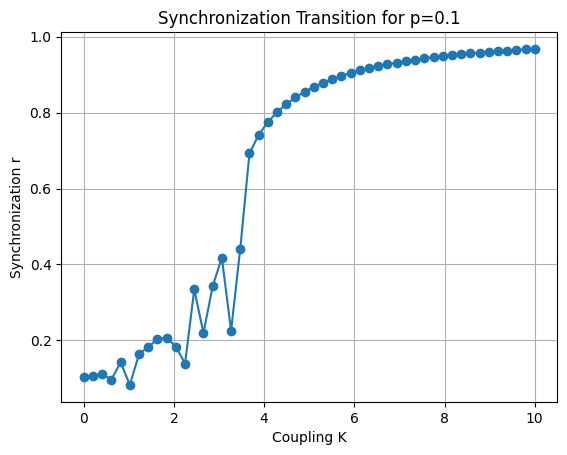

The number of degrees are 6.0
The minimum degree is 4.0 and the maximum degree is 8.0
[[0. 1. 1. ... 1. 1. 1.]
 [1. 0. 1. ... 0. 1. 1.]
 [1. 1. 0. ... 0. 0. 1.]
 ...
 [1. 0. 0. ... 0. 1. 1.]
 [1. 1. 0. ... 1. 0. 1.]
 [1. 1. 1. ... 1. 1. 0.]]


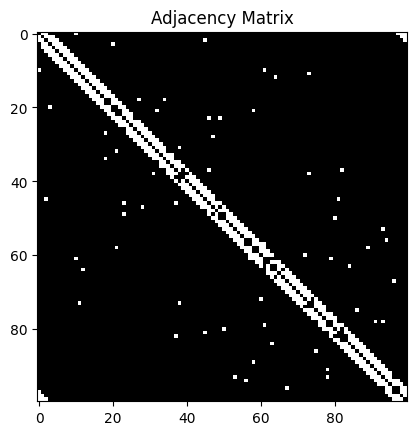

In [107]:
theta0 = np.random.uniform(0, 2*np.pi, N)

K_values = np.linspace(0, 10, 50)
r_final = []

for K in K_values:
    r = simulate(A, omega, K, theta0)
    r_final.append(np.mean(r[int(0.8*len(r)):]))

plt.plot(K_values, r_final, 'o-')
plt.xlabel("Coupling K")
plt.ylabel("Synchronization r")
plt.title("Synchronization Transition for p=0.1")
plt.grid()
plt.show()

degrees = np.sum(A, axis=1)
print('The number of degrees are',np.mean(degrees))   # should be ~6
print('The minimum degree is', np.min(degrees), 'and the maximum degree is', np.max(degrees))

print(A)
plt.imshow(A, cmap='gray')
plt.title("Adjacency Matrix")
plt.show()


In [78]:
print(K,p)

10.0 1


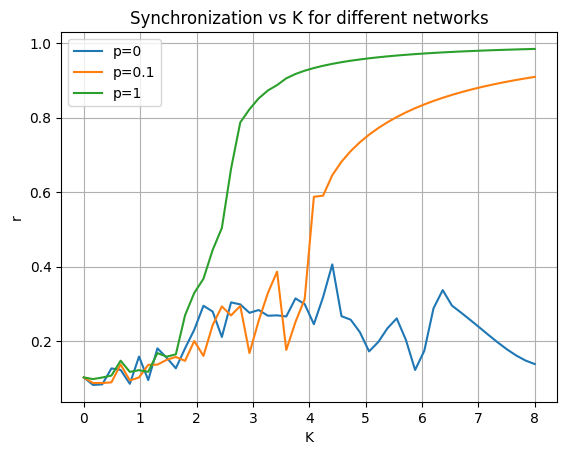

In [108]:
p_values = [0, 0.1, 1]
K_values = np.linspace(0, 8, 50)

for p in p_values:
    A = watts_strogatz(N, k, p)

    r_final = []
    for K in K_values:
        r = simulate(A, omega, K, theta0)
        r_final.append(np.mean(r[int(0.8*len(r)):]))
    
    plt.plot(K_values, r_final, label=f"p={p}")
    


plt.legend()
plt.xlabel("K")
plt.ylabel("r")
plt.title("Synchronization vs K for different networks")
plt.grid()
plt.show()

In [ ]:
# find approximate Kc (Through simulation results where r starts to increase rapidly)
dr = np.diff(r_final)
idx = np.argmax(dr)
Kc = K_values[idx]
print("Approximate Kc =", Kc)

Approximate Kc = 1.5789473684210527


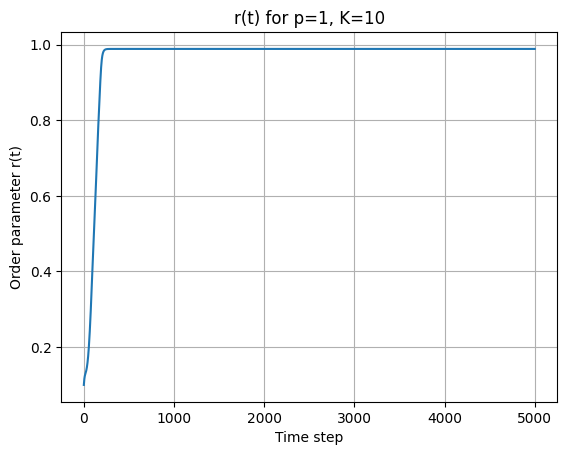

10 1


In [84]:
# r(t) plot
plt.plot(r)
plt.xlabel("Time step")
plt.ylabel("Order parameter r(t)")
plt.title(f"r(t) for p={p}, K={K}")
plt.grid()
plt.show()
print(K,p)



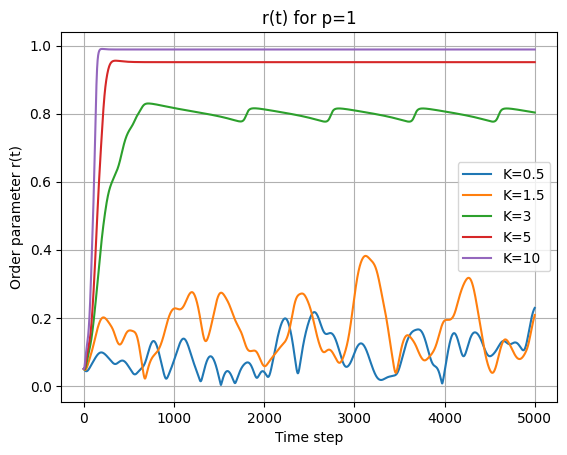

In [86]:
K_list = [0.5, 1.5, 3, 5,10]   # choose representative K values
theta0 = np.random.uniform(0, 2*np.pi, N)

plt.figure()

for K in K_list:
    r = simulate(A, omega, K, theta0)
    plt.plot(r, label=f"K={K}")

plt.xlabel("Time step")
plt.ylabel("Order parameter r(t)")
plt.title(f"r(t) for p={p}")
plt.legend()
plt.grid()
plt.show()


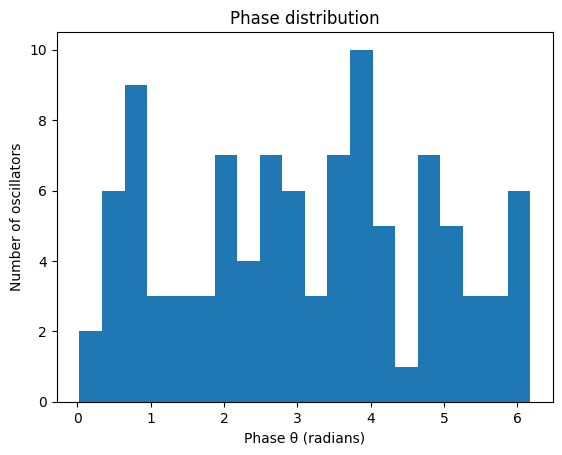

In [87]:
# Phase histogram
plt.hist(theta % (2*np.pi), bins=20)
plt.xlabel("Phase θ (radians)")
plt.ylabel("Number of oscillators")
plt.title("Phase distribution")
plt.show()

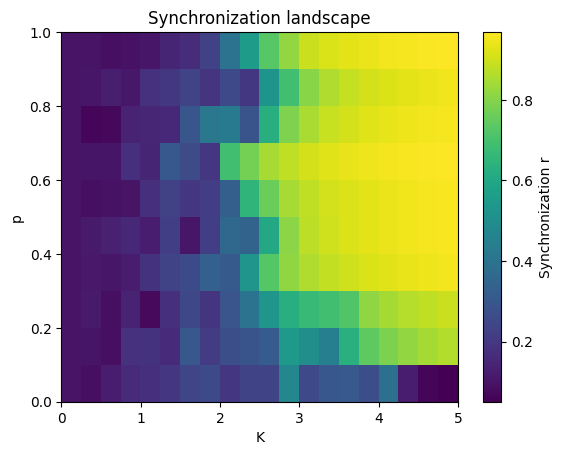

In [88]:
p_values = np.linspace(0, 1, 10)
K_values = np.linspace(0, 5, 20)

heatmap = np.zeros((len(p_values), len(K_values)))

for i, p in enumerate(p_values):
    A = watts_strogatz(N, k, p)
    
    for j, K in enumerate(K_values):
        r = simulate(A, omega, K, theta0)
        heatmap[i, j] = np.mean(r[int(0.8*len(r)):])

plt.imshow(heatmap, aspect='auto', origin='lower',
           extent=[K_values[0], K_values[-1], p_values[0], p_values[-1]])

plt.colorbar(label='Synchronization r')
plt.xlabel("K")
plt.ylabel("p")
plt.title("Synchronization landscape")
plt.show()

# Results and Interpretation

###  1. Global Synchronization Behavior
- The order parameter \( r \) is used to quantify synchronization.
- For small coupling strength \( K \), \( r \approx 0 \), indicating **incoherent dynamics**.
- As \( K \) increases, \( r \) increases, showing the emergence of **collective synchronization**.

---

###  2. Critical Coupling Strength \( K_c \)
- A transition point is observed where \( r \) starts increasing significantly.
- This value is identified as the **critical coupling strength \( K_c \)**.
- It marks the onset of synchronization in the system.

---

###  3. Partial Synchronization
- In the intermediate regime, \( 0 < r < 1 \), the system exhibits **partial synchronization**.
- A subset of oscillators becomes phase-locked, while others continue to drift.
- This indicates coexistence of **locked and drifting populations**.

---

###  4. Time Evolution of Synchronization
- The evolution of \( r(t) \) shows:
  - For small \( K \): no growth → no synchronization.
  - For large \( K \): rapid growth and saturation.
- This demonstrates how synchronization develops dynamically over time.

---

###  5. Effect of Network Topology (Rewiring Probability \( p \))
- Increasing \( p \) leads to:
  - Lower critical coupling \( K_c \)
  - Faster synchronization
- **Regular network (\( p = 0 \))**:
  - Requires higher \( K \) for synchronization
- **Small-world network (\( p = 0.1 \))**:
  - Synchronizes more efficiently due to shortcuts
- **Random network (\( p = 1 \))**:
  - Exhibits strongest and fastest synchronization

---

###  6. Phase Distribution
- At low \( K \): phases are uniformly distributed → incoherent state
- At high \( K \): phases cluster → synchronized state
- This confirms that synchronization corresponds to **phase alignment**

---

###  7. Overall Conclusion
- Synchronization emerges due to the interplay of:
  - Coupling strength \( K \)
  - Network structure \( p \)
- Small-world and random networks enhance synchronization due to **long-range connections**.
- The system exhibits a **continuous transition** from disorder to order.

---